# **NLP Básico**

Descripción

## **Librerías**

In [1]:
import os
import re

In [2]:
import spacy
import unicodedata

In [3]:
import pandas as pd

In [4]:
import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go

import bar_chart_race as bcr

In [5]:
from collections import Counter, defaultdict

In [6]:
from sentence_transformers import SentenceTransformer

c:\Users\jmart\Documents\Proyectos\Data_Science\Proyectos\NLP_WoT\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
from sklearn.cluster import AgglomerativeClustering

## **Variables Globales**

In [8]:
path_files = '../Data/Clean/01_EOdM/'

capitulos = os.listdir(path_files)
nombre_cap = capitulos[0]

## **Procesamiento del texto**

In [9]:
# !python -m spacy download es_core_news_lg

In [10]:
# Cargamos el modelo de español de spacy
nlp_sm = spacy.load('es_core_news_sm')
nlp_md = spacy.load('es_core_news_md')
nlp_lg = spacy.load('es_core_news_lg')

In [11]:
# Leemos nuestro texto
with open(f'{path_files}/{nombre_cap}', encoding='utf-8') as file:
    text = file.read()

### **Limpieza del texto**

In [12]:
# Quitamos las tildes
clean_text = unicodedata.normalize('NFKD', text).encode("ascii", "ignore").decode("utf-8")

# Quitamos los caracteres especiales
clean_text = re.sub(r"[^a-zA-Z\s]", "", clean_text)

# Convertimos el texto a minúsculas
clean_text = clean_text.lower()

In [13]:
# Creamos un documento con el modelo de spacy
doc = nlp_sm(clean_text)

In [14]:
# Proceso de tokenización
tokens = []

for token in doc:
    if not token.is_stop and not token.is_punct and len(token) > 2:
        tokens.append(token.lemma_)

In [15]:
def text_processor(raw_text: str, model):
    
    # Quitamos las tildes
    clean_text = unicodedata.normalize('NFKD', raw_text).encode("ascii", "ignore").decode("utf-8")

    # Quitamos los caracteres especiales
    clean_text = re.sub(r"[^a-zA-Z\s]", "", clean_text)

    # # Convertimos el texto a minúsculas
    # clean_text = clean_text.lower()
    
    # Creamos un documento con el modelo de spacy
    doc = model(clean_text)

    # Proceso de tokenización
    tokens = []

    for token in doc:
        if not token.is_stop and not token.is_punct and len(token) > 2:
            tokens.append(token.lemma_)

    return doc, tokens

### **Identificación de personajes**

#### **Modelo Small**

In [16]:
doc, tokens = text_processor(text, nlp_sm)

In [17]:
characters = [ent.text for ent in doc.ents if ent.label_ == 'PER']
characters_counter = Counter(characters)

In [18]:
pd.DataFrame(
    characters_counter.items(), 
    columns=['Personaje', 'Conteo']).sort_values(
        by='Conteo', 
        ascending=False
    ).head(10)

,Personaje,Conteo
7,Rand,14
37,Cenn,9
2,Bel Tine,7
1,Bela,7
21,Bueno,5
49,Dav,3
3,Tam,3
26,Zahori,2
5,Miro,2
29,Daise,2


Este conteo se esta quedando corto en varios aspectos. 

- En primer lugar, no esta logrando asociar a los personajes con claridad, el mismo personaje puede salir varias veces lo que distorsiona el ejercicio.
- No identifica a todos los personajes.
- Trae tokens que no corresponden a personajes

#### **Modelo Medium**

In [19]:
doc, tokens = text_processor(text, nlp_md)

In [20]:
characters = [ent.text for ent in doc.ents if ent.label_ == 'PER']
characters_counter = Counter(characters)

In [21]:
pd.DataFrame(
    characters_counter.items(), 
    columns=['Personaje', 'Conteo']).sort_values(
        by='Conteo', 
        ascending=False
    ).head(10)

,Personaje,Conteo
0,Rand,26
2,Tam,22
44,Cenn,9
29,Bran,6
30,Wit,5
31,Nynaeve,4
26,Bueno,4
18,Egwene,3
4,Dos Rios,2
32,Zahori,2


Cambiando el tamaño del modelo de spacy podemos observar que esta identificando muchas más entidades (personajes) y en este caso logra tener más precisión a la hora de detecar el personaje PoV. Sin embargo sigue fallando con que el mismo personaje sale representado más de una vez. 

#### **Modelo Large**

In [22]:
doc, tokens = text_processor(text, nlp_lg)

In [23]:
characters = [ent.text for ent in doc.ents if ent.label_ == 'PER']
characters_counter = Counter(characters)

In [24]:
pd.DataFrame(
    characters_counter.items(), 
    columns=['Personaje', 'Conteo']).sort_values(
        by='Conteo', 
        ascending=False
    ).head(10)

,Personaje,Conteo
0,Rand,33
4,Tam,18
43,Cenn,9
3,Bela,8
23,Bran,7
51,Mat,5
24,Wit,5
5,Bel Tine,5
50,Dav,4
16,Egwene,3


In [25]:
def detect_characters(text: str, nlp_model: SentenceTransformer, column_name: str = 'Conteo'):
    doc, _ = text_processor(text, nlp_model)

    characters = [ent.text for ent in doc.ents if ent.label_ == 'PER']
    characters_counter = Counter(characters)

    df_characters_counter = pd.DataFrame(
    characters_counter.items(), 
    columns=['Personaje', column_name]).sort_values(
        by=column_name, 
        ascending=False
    ).head(10)

    return characters_counter, df_characters_counter

Definitivamente el modelo small no funciona muy bien. Estoy en un dilema porque en algunos casos funciona mejor el modelo large, pero hay otros en los que el medium se ajusta mejor al comportamiento esperado.

Pasos a seguir:

- Vamos a modularizar el tema de los embeddings (para la agrupación de personajes que salen repetidos varias veces)
- Con eso vamos a comparar de manera más objetiva la identificación de personajes, aquí solo estamos viendo las primeras 10 filas, puede que abajo este quedandose info importante por el ruido
- Dependiendo de eso evaluaremos si nos vamos con un solo modelo o si jugamos a aplicar un sistema de reglas que los combine a ambos.
- Con esto asi ya vamos a poder identificar al personaje principal de cada capitulo (Esto va a ser bien curioso para el primer libro, porque se espera que casi siempre sea Rand, lo que se me ocurre es ver como los otros personajes van cambiando su relevancia a lo largo del libro)

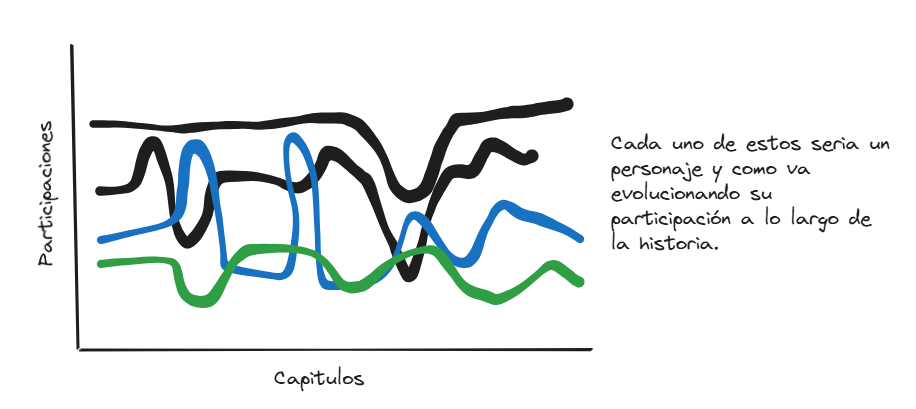

Algo asi se me ocurre para la primera visualización

In [26]:
# Inicializamos el modelo
sentence_model = SentenceTransformer('distiluse-base-multilingual-cased-v1')

In [27]:
# Enlistamos a nuestros personajes
pers_raw = list(characters_counter)
# Vectorizamos la lista de personajes
embeddings = sentence_model.encode(pers_raw)

# Usamos ML para construir un modelo de clustering para agrupar personajes
clustering = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=0.7
)

# Ajustamos el modelo a los embeddings 
labels = clustering.fit_predict(embeddings)

# Inicializamos un diccionario de listas
grupos = defaultdict(list)

# Agrupamos cada personaje al cluster correspondiente
for label, nombre in zip(labels, pers_raw):
    grupos[label].append(nombre)

# Inicializamos un diccionario para los resultados finales
representaciones = {}

# Ahora asignamos a cada entidad el cluster (personaje) que la representa
for label, nombres in grupos.items():
    representante = min(nombres, key=len)
    
    for nombre in nombres:
        representaciones[nombre] = representante

In [28]:
def character_cluster(character_counter: Counter, distance_threshold: float, column_name: str = 'Conteo'):
    # Inicializamos el modelo
    sentence_model = SentenceTransformer('distiluse-base-multilingual-cased-v1')

    # Enlistamos a nuestros personajes
    character_raw = list(character_counter)
    # Vectorizamos la lista de personajes
    embeddings = sentence_model.encode(character_raw)

    # Usamos ML para construir un modelo de clustering para agrupar personajes
    clustering = AgglomerativeClustering(
        n_clusters=None,
        distance_threshold=distance_threshold
    )

    # Ajustamos el modelo a los embeddings 
    labels = clustering.fit_predict(embeddings)

    # Inicializamos un diccionario de listas
    grupos = defaultdict(list)

    # Agrupamos cada personaje al cluster correspondiente
    for label, nombre in zip(labels, pers_raw):
        grupos[label].append(nombre)

    # Inicializamos un diccionario para los resultados finales
    representaciones = {}

    # Ahora asignamos a cada entidad el cluster (personaje) que la representa
    for label, nombres in grupos.items():
        representante = min(nombres, key=len)
        
        for nombre in nombres:
            representaciones[nombre] = representante

    # Construimos un DataFrame con los personajes que más aparecen
    df = pd.DataFrame(
        Counter([i[1] for i in representaciones.items()]).items(), 
        columns=['Personaje', column_name]).sort_values(
            by='Conteo', 
            ascending=False
    ).head(7)

    return df

In [29]:
models = {
    'es_core_news_sm': nlp_sm,
    'es_core_news_md': nlp_md,
    'es_core_news_lg': nlp_lg
}
thresholds = [0.5, 0.7, 0.9, 1]

df_results = pd.DataFrame()

for name_model, model in models.items():
    characters_counter, df_ini_counter = detect_characters(text, model)

    for threshold in thresholds:
        df_end_counter = character_cluster(characters_counter, threshold)
        
        df_end_counter['model'] = name_model
        df_end_counter['threshold'] = threshold

        df_results = pd.concat([df_results, df_end_counter])

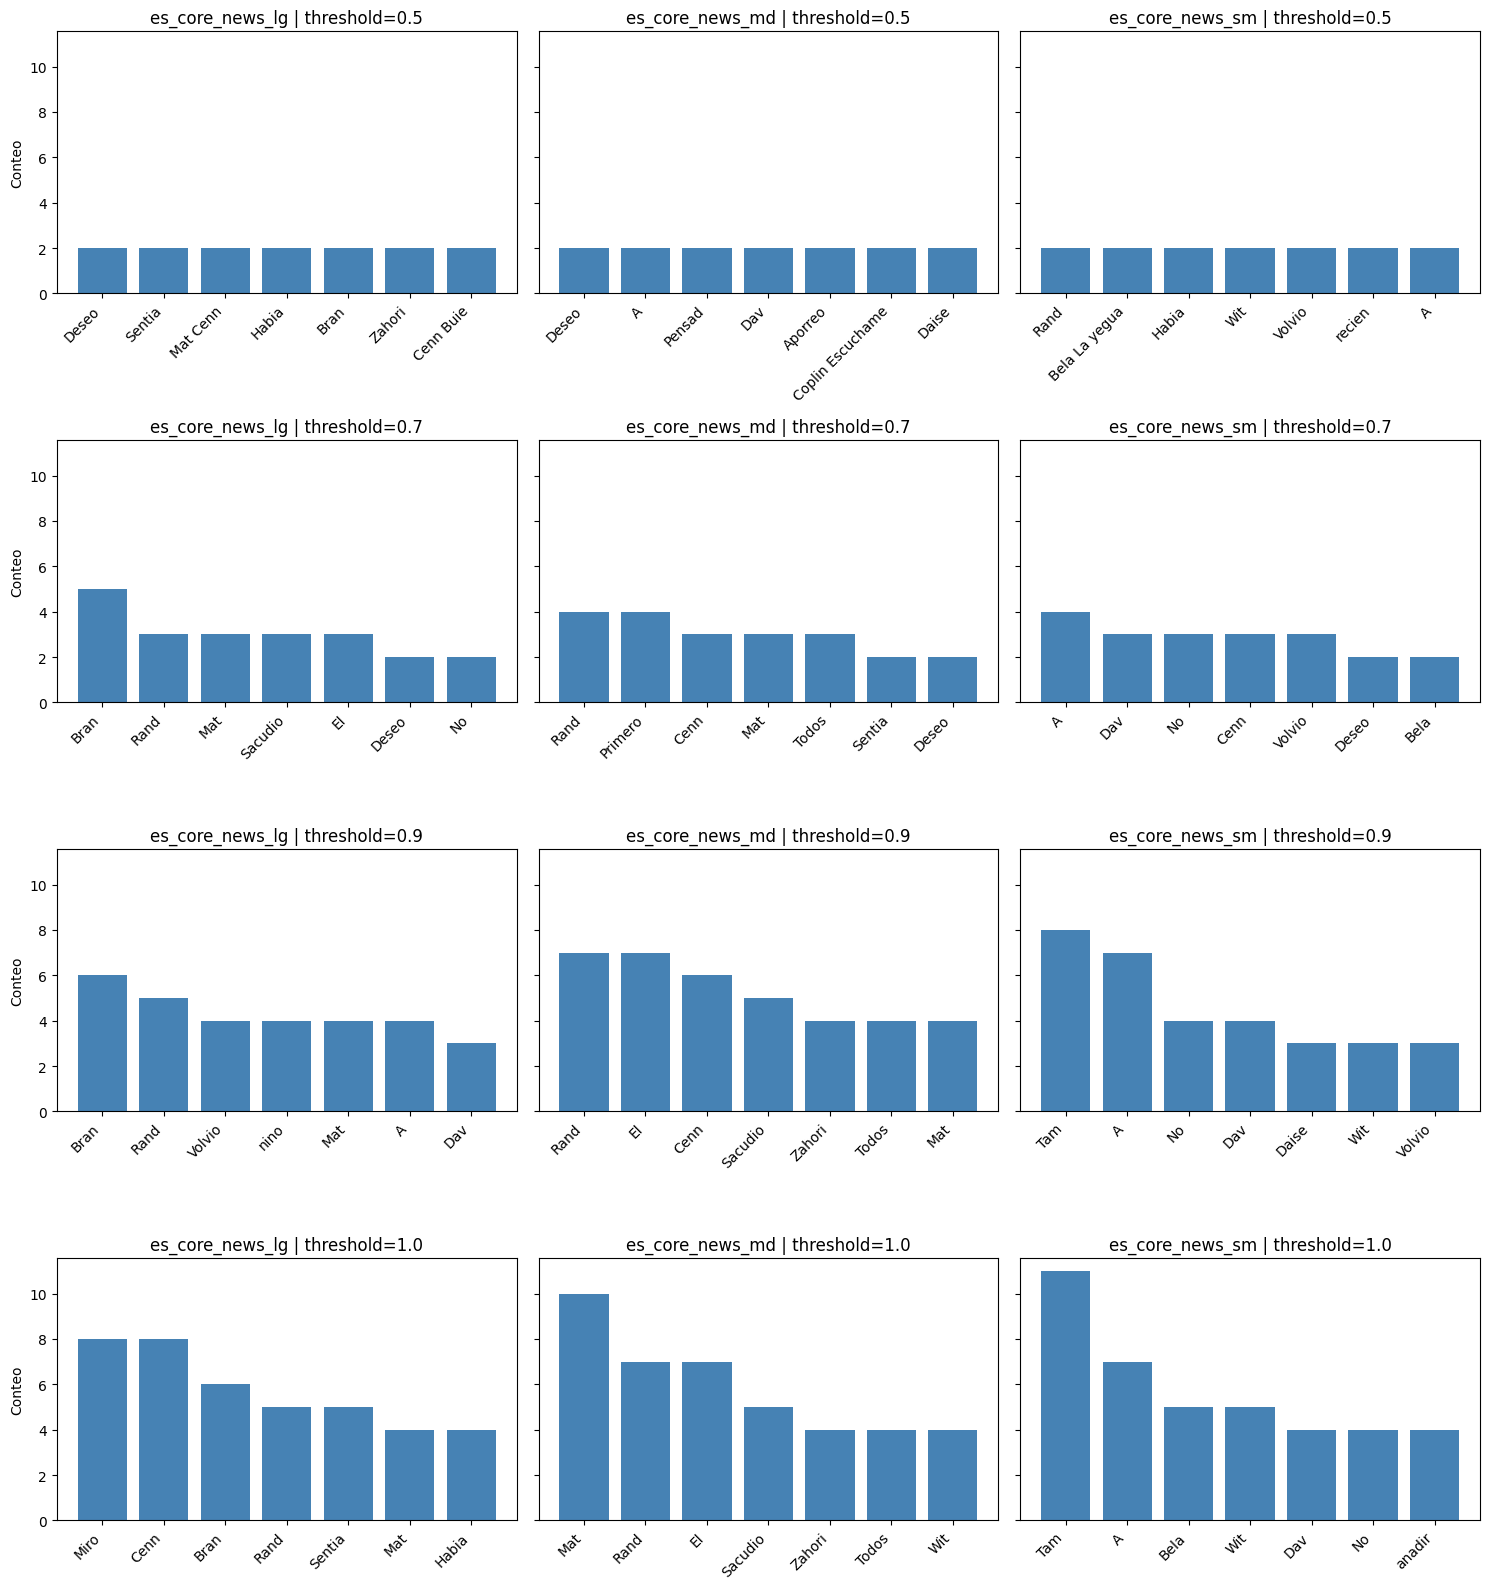

In [30]:
# Obtener listas únicas de modelos y thresholds
modelos = sorted(df_results['model'].unique())
thresholds = sorted(df_results['threshold'].unique())

# Definir el tamaño de la grilla
nrows = len(thresholds)
ncols = len(modelos)

# Crear los subplots
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows), sharey=True)

# Asegurar que axs sea una matriz bidimensional
if nrows == 1:
    axs = [axs]
if ncols == 1:
    axs = [[ax] for ax in axs]

# Recorrer cada combinación de threshold y modelo
for i, threshold in enumerate(thresholds):
    for j, model in enumerate(modelos):
        ax = axs[i][j]
        
        # Filtrar el DataFrame por modelo y threshold
        subset = df_results[(df_results['model'] == model) & (df_results['threshold'] == threshold)]
        subset_sorted = subset.sort_values('Conteo', ascending=False)

        # Dibujar gráfico de barras
        ax.bar(subset_sorted['Personaje'], subset_sorted['Conteo'], color='steelblue')
        ax.set_title(f'{model} | threshold={threshold}')
        ax.set_xticks(range(len(subset_sorted)))
        ax.set_xticklabels(subset_sorted['Personaje'], rotation=45, ha='right')

        if j == 0:
            ax.set_ylabel('Conteo')

# Ajustar el layout
plt.tight_layout()
plt.show()

#### **Ejercicio para todos los capitulos**

In [101]:
df_character_counter = pd.DataFrame({
    'Personaje': []
})

for capitulo in enumerate(capitulos):
    print(capitulo)
    # Leemos nuestro texto
    with open(f'{path_files}/{capitulo[1]}', encoding='utf-8') as file:
        text = file.read()

    _, df_ini_counter = detect_characters(text, nlp_lg, f'Capitulo_{capitulo[1][:2]}')
    
    df_character_counter = pd.merge(
        df_character_counter,
        df_ini_counter,
        how='outer',
        on='Personaje'
    )
    

(0, '01.un_camino_solitario.txt')
(1, '02.forasteros.txt')
(2, '03.el_buhonero.txt')
(3, '04.el_juglar.txt')
(4, '05.la_noche_de_invierno.txt')
(5, '06.el_bosque_del_oeste.txt')
(6, '07.a_la_salida_del_bosque.txt')
(7, '08.un_cobijo_acogedor.txt')
(8, '09.revelaciones_de_la_rueda.txt')
(9, '10.la_partida.txt')
(10, '11.la_ruta_hacia_el_embarcadero_de_taren.txt')
(11, '12.la_travesia_del_taren.txt')
(12, '13.elecciones.txt')
(13, '14.el_ciervo_y_el_leon.txt')
(14, '15.extranos_y_amigos.txt')
(15, '16.la_zahori.txt')
(16, '17.vigilantes_y_perseguidores.txt')
(17, '18.el_camino_de_caemlyn.txt')
(18, '19.sombras_en_ciernes.txt')
(19, '20.diseminados_por_el_viento.txt')
(20, '21.la_voz_del_viento.txt')
(21, '22.la_senda_elegida.txt')
(22, '23.hermano_lobo.txt')
(23, '24.el_descenso_por_el_arinelle.txt')
(24, '25.el_pueblo_errante.txt')
(25, '26.puente_blanco.txt')
(26, '27.al_abrigo_de_la_tormenta.txt')
(27, '28.huellas_en_el_aire.txt')
(28, '29.ojos_implacables.txt')
(29, '30.hijos_de_las_

In [102]:
df_character_counter.fillna(0, inplace=True)

In [103]:
df_character_counter

,Personaje,Capitulo_01,Capitulo_02,Capitulo_03,Capitulo_04,Capitulo_05,Capitulo_06,Capitulo_07,Capitulo_08,Capitulo_09,...,Capitulo_44,Capitulo_45,Capitulo_46,Capitulo_47,Capitulo_48,Capitulo_49,Capitulo_50,Capitulo_51,Capitulo_52,Capitulo_53
0,A,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,A Rand,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Ademas,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Aemon,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Aes Sedai,0.0,0.0,3.0,0.0,0.0,0.0,9.0,10.0,7.0,...,0.0,6.0,0.0,4.0,4.0,2.0,0.0,0.0,0.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,desperdiciarian,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
156,lady Moraine,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
157,lisa,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
158,rubi,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [143]:
df_melt = pd.melt(
    df_character_counter,
    id_vars=['Personaje'],
    var_name='Capitulo',
    value_vars= [f'Capitulo_{i[:2]}' for i in capitulos],
    value_name='Conteo'
)

In [144]:
df_top_characters = df_melt.groupby('Personaje').agg({
    'Conteo': ['sum']
}).reset_index().sort_values(by=('Conteo', 'sum'), ascending=False).head(5)

In [145]:
df_top_characters.columns = ['Personaje', 'Total_Conteo']
df_top_characters.reset_index(drop=True, inplace=True)

In [146]:
df_melt = pd.merge(
    df_melt,
    df_top_characters,
    how='left',
    on='Personaje'
)

In [169]:
color_discrete_map={
    'Rand': '#C0392B',
    'Mat': '#27AE60',
    'Moiraine': '#2980B9',
    'Egwene': '#8E44AD',
    'Perrin': '#F1C40F'
}


In [170]:
fig = px.line(
    df_melt.query('Total_Conteo > 0'),
    x='Capitulo',
    y='Conteo',
    color='Personaje',
    title='Conteo de Personajes por Capítulo',
    markers=True,
    color_discrete_map=color_discrete_map
)

fig.update_layout(
    title = dict(
        text = 'Conteo de personajes por capítulo',
        x = 0.5,
        xanchor = 'center',
        y = 0.95,
        font = dict(
            weight = 'bold',
            color = 'rgba(0, 0, 0, 0.95)'
        )
    ),
    xaxis = dict(
        title = 'Capitulos',
        showline = True,
        linecolor = 'black',
        showgrid = False,
        gridcolor = 'lightgrey',
        range = [0, 50],
        ticks ='outside',

    ),
    yaxis = dict(
        title = 'Conteo de menciones',
        showline = True,
        linecolor = 'black',
        showgrid = False,
        ticks ='outside',
    ),
    plot_bgcolor = 'rgba(256, 256, 256, 1)',
    paper_bgcolor = 'rgba(256, 256, 256, 1)'

)

fig.show()

In [167]:
capitulos[47 - 1]

'47.otras_historias_de_la_rueda_del_tiempo.txt'

In [137]:
df_melt['Conteo_acumulado'] = df_melt.groupby('Personaje')['Conteo'].cumsum()

In [138]:
df_resume = pd.crosstab(
    index=df_melt.query('Total_Conteo > 0')['Capitulo'],
    columns=df_melt.query('Total_Conteo > 0')['Personaje'],
    values=df_melt.query('Total_Conteo > 0')['Conteo_acumulado'],
    aggfunc='sum'
)

In [ ]:
list(color_discrete_map.values())

['#C0392B', '#27AE60', '#2980B9', '#8E44AD', '#F1C40F']

In [ ]:
bcr.bar_chart_race(
    df_resume,
    # period_length=
    cmap=[
        '#C0392B',  # Rand
        '#F1C40F',  # Mat
        '#2980B9',  # Moiraine
        '#8E44AD',  # Egwene
        '#27AE60',  # Perrin
        '#7F8C8D',  # Tam
        '#D35400',  # Thom
        '#A0522D',  # Loial
        '#34495E',  # Lan
        '#E74C3C'   # Aes Sedai
    ]

c:\Users\jmart\Documents\Proyectos\Data_Science\Proyectos\NLP_WoT\venv\Lib\site-packages\bar_chart_race\_make_chart.py:889: FutureWarning:

Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.

c:\Users\jmart\Documents\Proyectos\Data_Science\Proyectos\NLP_WoT\venv\Lib\site-packages\bar_chart_race\_make_chart.py:286: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

c:\Users\jmart\Documents\Proyectos\Data_Science\Proyectos\NLP_WoT\venv\Lib\site-packages\bar_chart_race\_make_chart.py:287: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

